# HW12 Traffic Sign Classification
Steps:
1. Load `data/subset_homework`
2. Visualize samples and count images per class
3. Train a baseline classifier with a single neuron
4. Improve the model with an MLP
5. Compare the results

In [10]:
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ROOT = Path("..")
DATASET_PATH = ROOT / "data" / "subset_homework"
RESULTS_PATH = ROOT / "results"
IMG_SIZE = 32

RESULTS_PATH.mkdir(parents=True, exist_ok=True)
print("Dataset path:", DATASET_PATH)
print("Results path:", RESULTS_PATH)
print("Dataset exists:", DATASET_PATH.exists())

Dataset path: ..\data\subset_homework
Results path: ..\results
Dataset exists: True


## Inspect dataset structure
Supported formats:

### Format A
```text
subset_homework/
├── 0/
├── 1/
└── ...
```

### Format B
```text
subset_homework/
├── train/
│   ├── 0/
│   ├── 1/
│   └── ...
└── test/
    ├── 0/
    ├── 1/
    └── ...
```

In [11]:
def inspect_dataset_structure(dataset_path, max_items=10):
    print(f"Inspecting: {dataset_path}\n")
    if not dataset_path.exists():
        print("Dataset folder does not exist.")
        return
    level1 = sorted(list(dataset_path.iterdir()))
    print("Top-level entries:")
    for p in level1[:max_items]:
        print(" -", p.name, "[DIR]" if p.is_dir() else "[FILE]")
    print("\nFolders and first few files inside:")
    for p in level1:
        if p.is_dir():
            files = sorted(list(p.iterdir()))
            print(f"\n{p.name}/")
            for f in files[:max_items]:
                print("   -", f.name, "[DIR]" if f.is_dir() else "[FILE]")

inspect_dataset_structure(DATASET_PATH)

Inspecting: ..\data\subset_homework

Top-level entries:
 - class_id_0 [DIR]
 - class_id_1 [DIR]

Folders and first few files inside:

class_id_0/
   - 0000.jpg [FILE]
   - 0001.jpg [FILE]
   - 0002.jpg [FILE]
   - 0003.jpg [FILE]
   - 0004.jpg [FILE]
   - 0005.jpg [FILE]
   - 0006.jpg [FILE]
   - 0007.jpg [FILE]
   - 0008.jpg [FILE]
   - 0009.jpg [FILE]

class_id_1/
   - 0000.jpg [FILE]
   - 0001.jpg [FILE]
   - 0002.jpg [FILE]
   - 0003.jpg [FILE]
   - 0004.jpg [FILE]
   - 0005.jpg [FILE]
   - 0006.jpg [FILE]
   - 0007.jpg [FILE]
   - 0008.jpg [FILE]
   - 0009.jpg [FILE]


## Load dataset

In [18]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".ppm"}

def read_image_gray(img_path, img_size=32):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def load_flat_class_folders(dataset_path, img_size=32):
    import re
    images = []
    labels = []
    class_counts = {}
    class_dirs = [p for p in sorted(dataset_path.iterdir()) if p.is_dir()]
    for class_dir in class_dirs:
        match = re.search(r"\d+", class_dir.name)
        if not match:
            continue
        label = int(match.group())
        class_counts[str(label)] = 0
        for file_path in sorted(class_dir.iterdir()):
            if file_path.suffix.lower() not in VALID_EXTENSIONS:
                continue
            img = read_image_gray(file_path, img_size)
            if img is None:
                continue
            images.append(img)
            labels.append(label)
            class_counts[str(label)] += 1
    if len(images) == 0:
        raise RuntimeError("No images were loaded from flat class folders.")
    return np.array(images), np.array(labels), class_counts

def load_train_test_class_folders(dataset_path, img_size=32):
    train_path = dataset_path / "train"
    test_path = dataset_path / "test"
    if not train_path.exists() or not test_path.exists():
        raise FileNotFoundError("train/ or test/ folder not found.")
    def load_split(split_path):
        split_images, split_labels, split_counts = [], [], {}
        class_dirs = [p for p in sorted(split_path.iterdir()) if p.is_dir()]
        for class_dir in class_dirs:
            if not class_dir.name.isdigit():
                continue
                
            label = int(class_dir.name)
            split_counts[str(label)] = 0
            for file_path in sorted(class_dir.iterdir()):
                if file_path.suffix.lower() not in VALID_EXTENSIONS:
                    continue
                img = read_image_gray(file_path, img_size)
                if img is None:
                    continue
                split_images.append(img)
                split_labels.append(label)
                split_counts[str(label)] += 1
        return np.array(split_images), np.array(split_labels), split_counts
    X_train_img, y_train, train_counts = load_split(train_path)
    X_test_img, y_test, test_counts = load_split(test_path)
    if len(X_train_img) == 0 or len(X_test_img) == 0:
        raise RuntimeError("No images were loaded from train/test folders.")
    return X_train_img, X_test_img, y_train, y_test, train_counts, test_counts

def load_data_auto(dataset_path, img_size=32):
    names = {p.name.lower() for p in dataset_path.iterdir() if p.is_dir()}
    if "train" in names and "test" in names:
        print("Detected structure: train/test folders")
        return {"mode": "train_test", "data": load_train_test_class_folders(dataset_path, img_size)}
    print("Detected structure: flat class folders")
    return {"mode": "flat", "data": load_flat_class_folders(dataset_path, img_size)}

In [19]:
print("Files in dataset:")
for p in DATASET_PATH.glob("*"):
    print(p)

Files in dataset:
..\data\subset_homework\class_id_0
..\data\subset_homework\class_id_1


In [20]:
loaded = load_data_auto(DATASET_PATH, IMG_SIZE)

if loaded["mode"] == "flat":
    images, labels, class_counts = loaded["data"]
    print("Loaded images:", len(images))
    print("Loaded labels:", len(labels))
    print("Classes:", sorted(class_counts.keys()))
    print("Mode: flat class folders")
else:
    X_train_img, X_test_img, y_train, y_test, train_counts, test_counts = loaded["data"]
    print("Train images:", len(X_train_img))
    print("Test images:", len(X_test_img))
    print("Train classes:", sorted(train_counts.keys()))
    print("Test classes:", sorted(test_counts.keys()))
    print("Mode: train/test split")

Detected structure: flat class folders
Loaded images: 4470
Loaded labels: 4470
Classes: ['0', '1']
Mode: flat class folders


## Visualize some examples

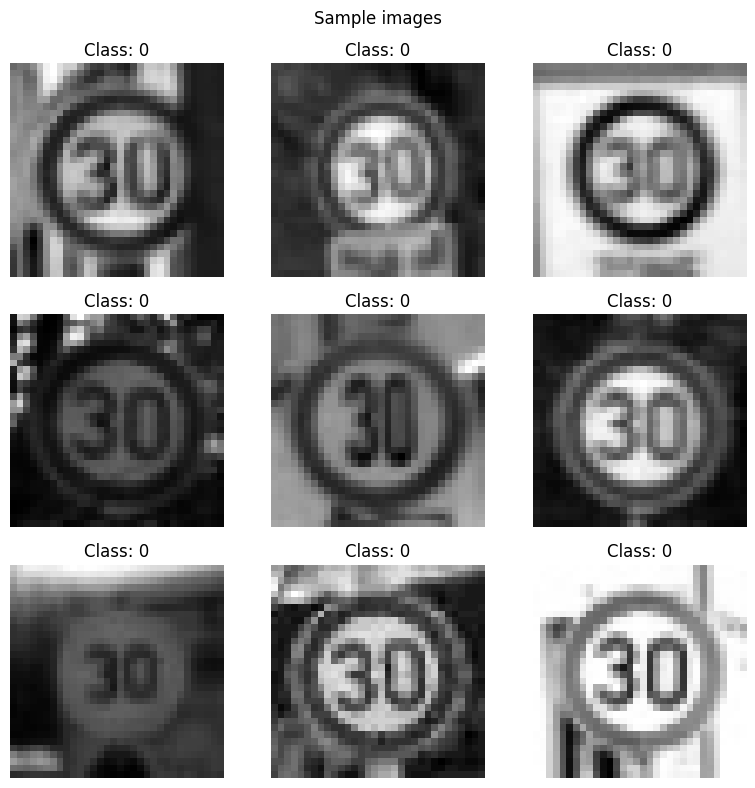

In [21]:
def visualize_samples(images, labels, title="Sample images", save_name="samples.png"):
    plt.figure(figsize=(8, 8))
    n = min(9, len(images))
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Class: {labels[i]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / save_name)
    plt.show()

if loaded["mode"] == "flat":
    visualize_samples(images, labels, title="Sample images", save_name="samples.png")
else:
    visualize_samples(X_train_img, y_train, title="Sample train images", save_name="samples_train.png")

## Count images per class

Class Distribution
Class 0: 2220 images
Class 1: 2250 images


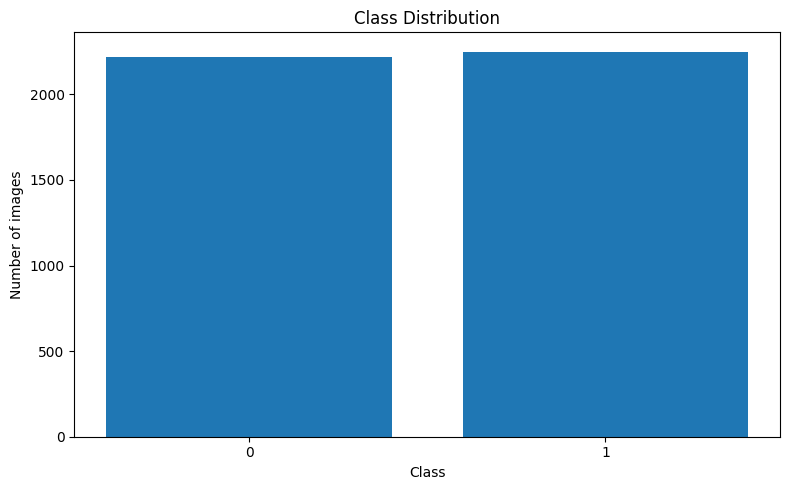

In [22]:
def plot_class_distribution(class_counts, title="Class Distribution", save_name="class_distribution.png"):
    labels_plot = list(class_counts.keys())
    counts_plot = list(class_counts.values())
    print(title)
    for cls, count in class_counts.items():
        print(f"Class {cls}: {count} images")
    plt.figure(figsize=(8, 5))
    plt.bar(labels_plot, counts_plot)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / save_name)
    plt.show()

if loaded["mode"] == "flat":
    plot_class_distribution(class_counts, "Class Distribution", "class_distribution.png")
else:
    plot_class_distribution(train_counts, "Train Class Distribution", "class_distribution_train.png")
    plot_class_distribution(test_counts, "Test Class Distribution", "class_distribution_test.png")

## Preprocessing

For the classifiers below:
- each image is flattened into a 1D vector
- pixel values are normalized to `[0, 1]`

In [23]:
def preprocess(images):
    return images.reshape(len(images), -1) / 255.0

if loaded["mode"] == "flat":
    X = preprocess(images)
    y = labels
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    X_train = preprocess(X_train_img)
    X_test = preprocess(X_test_img)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3576, 1024)
Test shape: (894, 1024)


## Train with one single neuron

Here we use **Logistic Regression** as a linear single-neuron baseline.

In [24]:
single_neuron_model = LogisticRegression(max_iter=1000)
single_neuron_model.fit(X_train, y_train)

y_pred_single = single_neuron_model.predict(X_test)
acc_single = accuracy_score(y_test, y_pred_single)

print(f"Single neuron accuracy: {acc_single:.4f}")

Single neuron accuracy: 0.9620


## Improve the model

Here we use an **MLPClassifier** with hidden layers `(128, 64)`.

In [25]:
mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"MLP accuracy: {acc_mlp:.4f}")

MLP accuracy: 0.9720


## Final comparison

In [26]:
print("=== FINAL RESULT ===")
print(f"Single neuron accuracy: {acc_single:.4f}")
print(f"MLP accuracy: {acc_mlp:.4f}")

print("\nClassification report for improved model:")
print(classification_report(y_test, y_pred_mlp))

=== FINAL RESULT ===
Single neuron accuracy: 0.9620
MLP accuracy: 0.9720

Classification report for improved model:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       444
           1       0.98      0.97      0.97       450

    accuracy                           0.97       894
   macro avg       0.97      0.97      0.97       894
weighted avg       0.97      0.97      0.97       894



## Confusion matrix for the improved model

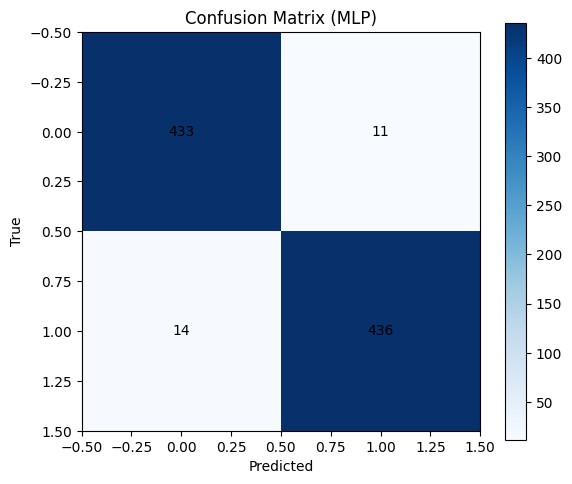

In [27]:
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (MLP)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig(RESULTS_PATH / "confusion_matrix.png")
plt.show()

## Homework Answers

## Step 1:
The dataset contains 2220 images for class 0 and 2250 images for class 1.

## Step 2:
Using a single neuron baseline model (Logistic Regression), the achieved accuracy was 0.9620.

## Step 3:
After improving the model with an MLP, the maximum achieved accuracy was 0.9720.

## Conclusion:
The MLP performed better than the single neuron model, but the improvement was moderate because the baseline accuracy was already very high.